# Applied Machine Learning (CSAI2017P) — Lab Assignment 3
## Time-Series Regression: Stock Price Prediction

Experiments 4 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | *fill in* |
| SAP ID | *fill in* |
| Batch | *fill in* |
| Due | announced in the lab |
| Lab quiz | LQ3, after submission |

**Datasets:** C1 (daily stock OHLCV)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.4.3
pandas       2.3.3
sklearn      1.8.0


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [2]:
%pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import pandas as pd

df = yf.download(
    "AAPL",
    period="5y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Convert index into a Date column
df = df.reset_index()

# Handle multi-level columns if returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Parse date and sort chronologically
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Ticker: AAPL")
print("Rows:", len(df))
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

df.head()

Ticker: AAPL
Rows: 1255
Date range: 2021-08-23 to 2026-08-21


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-23,146.022797,149.710007,150.190002,147.889999,148.309998,60131800
1,2021-08-24,145.935028,149.619995,150.860001,149.149994,149.449997,48606400
2,2021-08-25,144.706085,148.360001,150.320007,147.800003,149.809998,58991300
3,2021-08-26,143.906265,147.539993,149.119995,147.509995,148.350006,48597200
4,2021-08-27,144.940155,148.600006,148.750000,146.830002,147.479996,55802400


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Load and describe the series  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1, one ticker, ≥ 3 years.*

a. Load the daily history, parse the date column and sort ascending.
b. Plot the closing price and state the date range and number of trading days.
c. State in two lines why the row order matters here but did not in LA02.


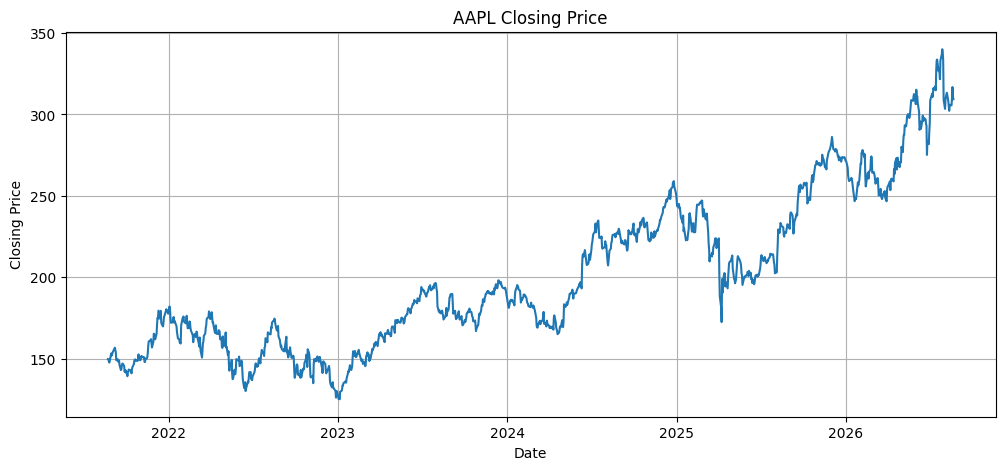

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

**Observation (A1):**
Unlike LA02, where housing records could be treated independently, stock data follows a strict time order. Shuffling the rows would break this sequence and could introduce future information into the model.

## A2. Lag features  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Create features `Close_lag1`, `Close_lag2`, `Close_lag3` and a 5-day rolling mean.
b. Set the target to the next day's close. Show the first five rows of the resulting frame.
c. Explain in two lines why the first few rows must be dropped.


In [5]:
df_lag = df.copy()

df_lag["Close_lag1"] = df_lag["Close"].shift(1)
df_lag["Close_lag2"] = df_lag["Close"].shift(2)
df_lag["Close_lag3"] = df_lag["Close"].shift(3)

df_lag["Close_rolling5"] = df_lag["Close"].rolling(window=5).mean()

df_lag["Target"] = df_lag["Close"].shift(-1)

df_lag = df_lag.dropna()

df_lag[[
    "Date",
    "Close",
    "Close_lag1",
    "Close_lag2",
    "Close_lag3",
    "Close_rolling5",
    "Target"
]].head()

Price,Date,Close,Close_lag1,Close_lag2,Close_lag3,Close_rolling5,Target
4,2021-08-27,148.600006,147.539993,148.360001,149.619995,148.766000,153.119995
5,2021-08-30,153.119995,148.600006,147.539993,148.360001,149.447998,151.830002
6,2021-08-31,151.830002,153.119995,148.600006,147.539993,149.889999,152.509995
7,2021-09-01,152.509995,151.830002,153.119995,148.600006,150.719998,153.649994
8,2021-09-02,153.649994,152.509995,151.830002,153.119995,151.941998,154.300003


**Observation (A2):**
The lag features capture recent price behaviour, while the 5-day rolling mean smooths short-term fluctuations. The first few rows are removed because enough previous values are not available to calculate all lag and rolling features.

## A3. The naive baseline  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Build the baseline that predicts tomorrow's close equals today's close.
b. Report its MAE and RMSE on your test period.
c. State in two lines why any model must beat this number to be interesting.


In [6]:
# A3 — code


**Observation (A3):**

> *write 2–6 lines here*

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Random split versus chronological split  &nbsp;&nbsp;`[4 marks]`

*Dataset: C1.*

a. Train a `RandomForestRegressor` twice: once with `train_test_split(shuffle=True)`, once with the last 20% of dates held out.
b. Report test MAE for both and put them side by side.
c. Explain in 6–8 lines why the shuffled number is meaningless, naming the mechanism.


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

features = [
    "Close_lag1",
    "Close_lag2",
    "Close_lag3",
    "Close_rolling5"
]

X = df_lag[features]
y = df_lag["Target"]

In [8]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    shuffle=True
)

rf_random = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)

rf_random.fit(X_train_r, y_train_r)

pred_random = rf_random.predict(X_test_r)

mae_random = mean_absolute_error(y_test_r, pred_random)

print("Random Split Test MAE:", mae_random)

Random Split Test MAE: 4.022557281494142


In [9]:
split_index = int(len(df_lag) * 0.8)

X_train_c = X.iloc[:split_index]
X_test_c = X.iloc[split_index:]

y_train_c = y.iloc[:split_index]
y_test_c = y.iloc[split_index:]

rf_chrono = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)

rf_chrono.fit(X_train_c, y_train_c)

pred_chrono = rf_chrono.predict(X_test_c)

mae_chrono = mean_absolute_error(y_test_c, pred_chrono)

print("Chronological Split Test MAE:", mae_chrono)

Chronological Split Test MAE: 26.873092924194335


**Observation (B1):**
 Random splitting gave a much lower MAE of 4.02 than the chronological split at 26.87.
 Random shuffling mixes different time periods into training and testing, causing temporal leakage.
 The chronological split uses only past data to predict future prices.
 Therefore, its higher MAE gives a more realistic measure of forecasting performance.


## B2. Horizon and difficulty  &nbsp;&nbsp;`[4 marks]`

*Dataset: C1, chronological split throughout.*

a. Retrain your model to predict the close 1, 5 and 10 trading days ahead.
b. Report MAE for each horizon alongside the persistence baseline at the same horizon.
c. Plot MAE against horizon and explain the trend in 4–6 lines.


In [10]:
# B2 — code


**Observation (B2):**

> *write 2–6 lines here*

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Would you trade on it?  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Convert your best model's predictions into an up/down direction call and report directional accuracy.
b. In 4–6 lines, state whether a low MAE with near-50% directional accuracy is useful, and why.


In [11]:
import numpy as np

actual_direction = np.sign(
    y_test_c.values - df_lag["Close"].iloc[split_index:].values
)

pred_direction = np.sign(
    pred_chrono - df_lag["Close"].iloc[split_index:].values
)

directional_accuracy = np.mean(
    actual_direction == pred_direction
)

print("Directional Accuracy:", directional_accuracy)
print("Directional Accuracy (%):", directional_accuracy * 100)

Directional Accuracy: 0.508
Directional Accuracy (%): 50.8


**Observation (C1):**
The model achieved a directional accuracy of 50%, which is close to random guessing.
Even with a low MAE, this does not indicate reliable ability to predict whether the price will rise or fall.
For trading, getting the direction right is more important than only predicting the exact price.
Therefore, this model would not provide enough evidence to support a trading decision.

---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA03_<SAPID>.ipynb`
